In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('D:\\Case Study\\data\\heart.csv')
df1 = pd.read_csv('D:\\Case Study\\data\\heart_disease_data.csv')

# Gộp 2 dataframe
df = pd.concat([df, df1], ignore_index=True)

# Tạo binary target nếu chưa có
if df['target'].max() > 1:
    df['target'] = (df['target'] > 0).astype(int)

continuous  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print(f"Shape: {df.shape}")
print(f"Target: {df['target'].value_counts().to_dict()}")

Shape: (1631, 14)
Target: {1: 856, 0: 775}


In [16]:

print("=" * 65)
print(f"{'Feature':<12} {'Group':<12} {'Mean':>8} {'Std':>8} {'P25':>8} {'P75':>8}")
print("=" * 65)

summary_rows = []
for col in continuous:
    for label, name in zip([0, 1], ['Không bệnh', 'Bệnh tim  ']):
        subset = df[df['target'] == label][col].values

        mean_val = np.mean(subset)
        std_val  = np.std(subset)
        p25      = np.percentile(subset, 25)
        p75      = np.percentile(subset, 75)

        summary_rows.append({
            'feature': col, 'target': label,
            'mean': mean_val, 'std': std_val,
            'p25': p25, 'p75': p75
        })
        print(f"{col:<12} {name:<12} {mean_val:>8.2f} {std_val:>8.2f} "
              f"{p25:>8.2f} {p75:>8.2f}")
    print()

summary_df = pd.DataFrame(summary_rows)

Feature      Group            Mean      Std      P25      P75
age          Không bệnh      56.58     7.91    52.00    62.00
age          Bệnh tim        52.44     9.58    44.00    59.00

trestbps     Không bệnh     134.21    18.60   120.00   144.00
trestbps     Bệnh tim       129.27    16.11   120.00   140.00

chol         Không bệnh     251.22    49.43   217.00   284.00
chol         Bệnh tim       241.46    53.13   208.00   266.00

thalach      Không bệnh     139.12    22.53   125.00   156.00
thalach      Bệnh tim       158.54    19.09   149.00   172.00

oldpeak      Không bệnh       1.59     1.29     0.60     2.50
oldpeak      Bệnh tim         0.58     0.77     0.00     1.00



In [17]:

print("=" * 60)
print("Kiểm tra Bất đẳng thức Chebyshev — thalach (nhịp tim)")
print("=" * 60)

data = df['thalach'].values
mu   = np.mean(data)
sig  = np.std(data)

print(f"Mean = {mu:.2f}  |  Std = {sig:.2f}\n")

for k in [2, 3]:
    chebyshev_bound = 1 - 1/k**2          # Giới hạn lý thuyết
    actual_pct = np.mean(
        np.abs(data - mu) <= k * sig
    )                                       # Thực tế trong data
    print(f"k={k}: Chebyshev dự đoán ≥ {chebyshev_bound:.0%} "
          f"| Thực tế: {actual_pct:.1%}")

# ── Normal approximation cho phân phối hình chuông ──────────────
print("\nNormal approximation (nếu phân phối hình chuông):")
for k in [1, 2, 3]:
    pct = np.mean(np.abs(data - mu) <= k * sig)
    print(f"  ±{k}σ: {pct:.1%}  (lý thuyết chuẩn: "
          f"{[68, 95, 99.7][k-1]}%)")

Kiểm tra Bất đẳng thức Chebyshev — thalach (nhịp tim)
Mean = 149.31  |  Std = 22.95

k=2: Chebyshev dự đoán ≥ 75% | Thực tế: 96.2%
k=3: Chebyshev dự đoán ≥ 89% | Thực tế: 99.6%

Normal approximation (nếu phân phối hình chuông):
  ±1σ: 66.0%  (lý thuyết chuẩn: 68%)
  ±2σ: 96.2%  (lý thuyết chuẩn: 95%)
  ±3σ: 99.6%  (lý thuyết chuẩn: 99.7%)


In [18]:

def to_standard_units(arr):
    """Chuyển sang đơn vị chuẩn: (x - mean) / std"""
    return (arr - np.mean(arr)) / np.std(arr)

def correlation(x, y):
    """r = mean của tích các giá trị standard units"""
    return np.mean(to_standard_units(x) * to_standard_units(y))

print("Hệ số tương quan r với target (tính theo Standard Units):")
print("=" * 50)
for col in continuous:
    r = correlation(df[col].values, df['target'].values)
    bar = '█' * int(abs(r) * 20)
    print(f"{col:<12}  r = {r:>7.4f}  {bar}")

Hệ số tương quan r với target (tính theo Standard Units):
age           r = -0.2279  ████
trestbps      r = -0.1410  ██
chol          r = -0.0944  █
thalach       r =  0.4226  ████████
oldpeak       r = -0.4358  ████████


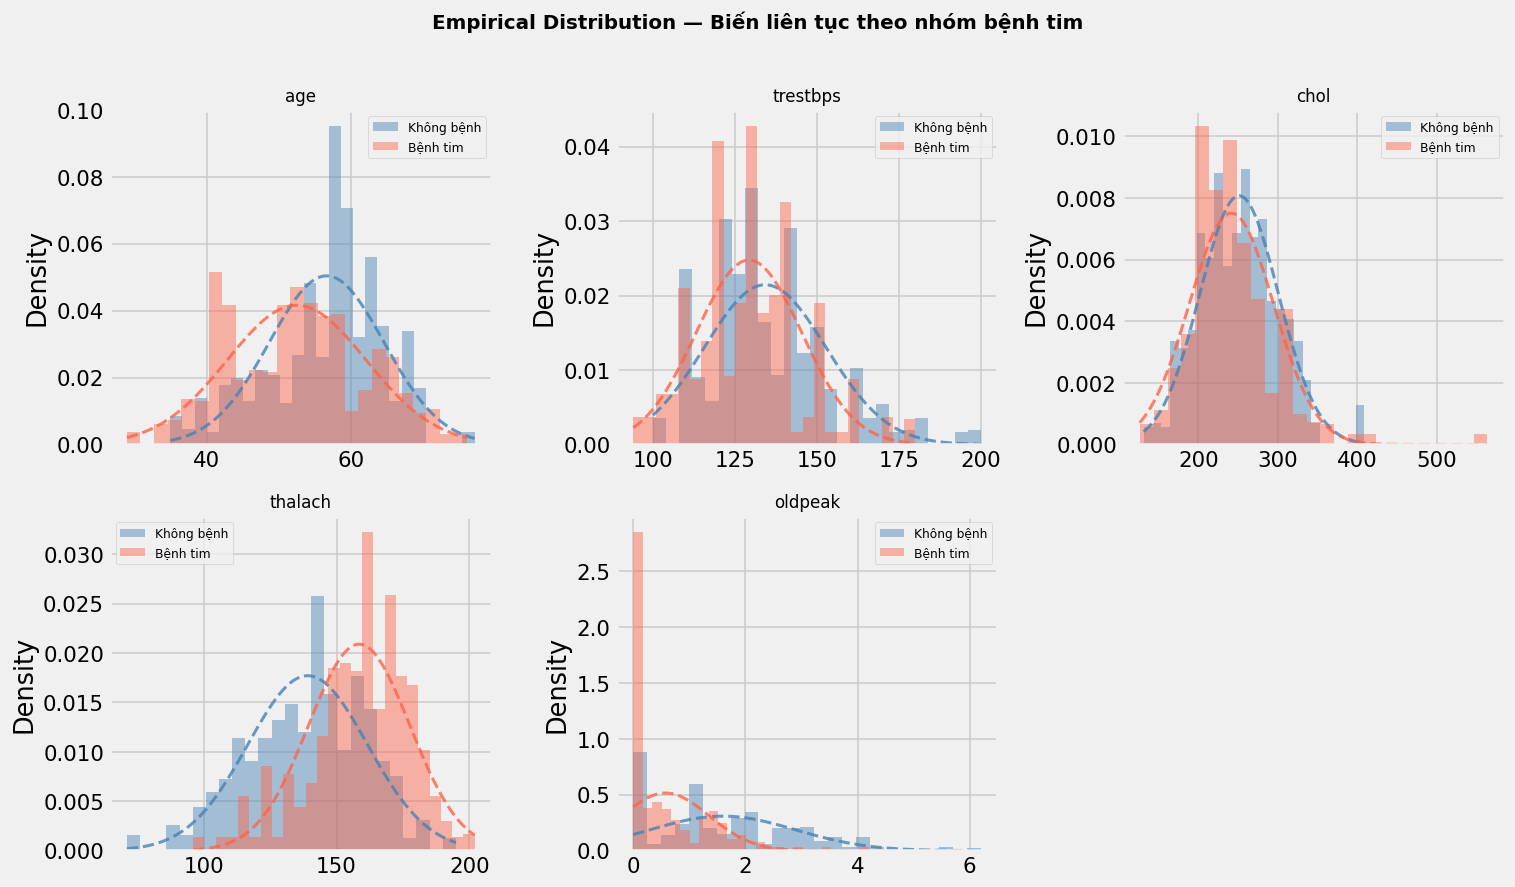

In [19]:
# Empirical distribution — histogram
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(continuous):
    for label, color, name in zip(
        [0, 1], ['steelblue', 'tomato'],
        ['Không bệnh', 'Bệnh tim']
    ):
        subset = df[df['target'] == label][col]
        axes[i].hist(subset, bins=25, alpha=0.45,
                     color=color, density=True, label=name)
        x = np.linspace(subset.min(), subset.max(), 100)
        mu_s  = np.mean(subset)
        sig_s = np.std(subset)
        axes[i].plot(x,
            np.exp(-0.5*((x-mu_s)/sig_s)**2) / (sig_s*np.sqrt(2*np.pi)),
            color=color, linewidth=2, linestyle='--', alpha=0.8)

    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('Empirical Distribution — Biến liên tục theo nhóm bệnh tim',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

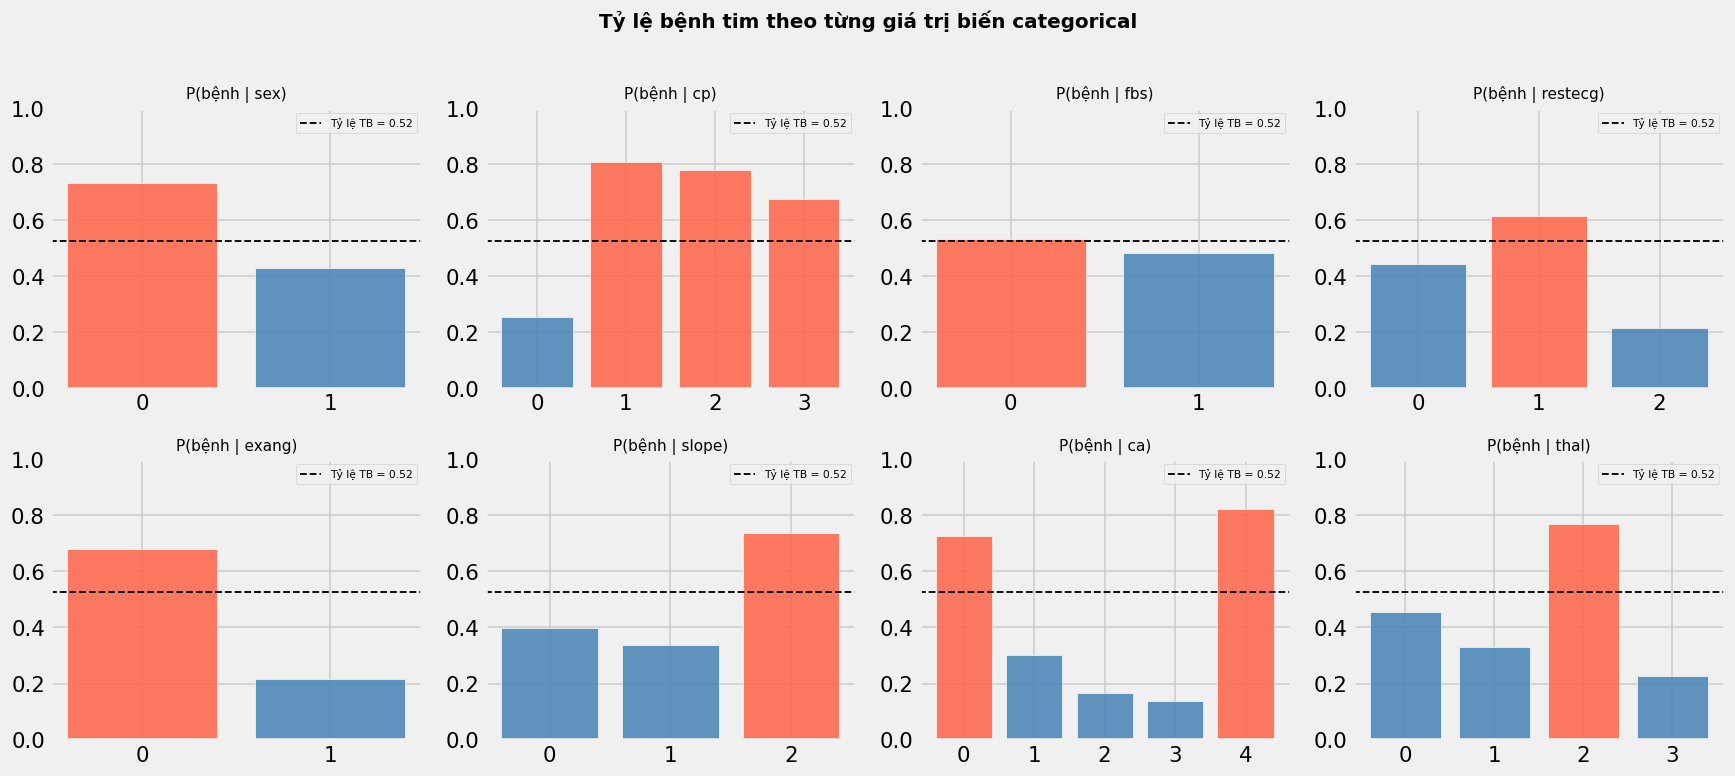

In [20]:
# Tỷ lệ bệnh theo từng giá trị biến categorical
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

overall_rate = df['target'].mean()   # baseline

for i, col in enumerate(categorical):
    rate = df.groupby(col)['target'].mean()
    colors = ['tomato' if v > overall_rate else 'steelblue'
              for v in rate.values]
    axes[i].bar(rate.index.astype(str), rate.values,
                color=colors, edgecolor='white', alpha=0.85)
    axes[i].axhline(overall_rate, color='black',
                    linestyle='--', linewidth=1.2,
                    label=f'Tỷ lệ TB = {overall_rate:.2f}')
    axes[i].set_title(f'P(bệnh | {col})', fontsize=10)
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=7)

plt.suptitle('Tỷ lệ bệnh tim theo từng giá trị biến categorical',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Khác biệt mean giữa 2 nhóm → feature phân biệt tốt nhất
diff_df = summary_df.pivot_table(
    index='feature', columns='target', values='mean'
)
diff_df.columns = ['mean_no', 'mean_yes']
diff_df['diff'] = (diff_df['mean_yes'] - diff_df['mean_no']).abs()
diff_df['r_with_target'] = [
    abs(correlation(df[col].values, df['target'].values))
    for col in diff_df.index
]

print("\nKhác biệt mean và tương quan r với target:")
print(diff_df.sort_values('r_with_target', ascending=False).round(3))

diff_df.to_csv('D:\\Case Study\\data\\week1_summary.csv', index=False)
df.to_csv('D:\\Case Study\\data\\heart_ready.csv', index=False)
print("\n✅ Đã lưu week1_summary.csv | heart_ready.csv")


Khác biệt mean và tương quan r với target:
          mean_no  mean_yes    diff  r_with_target
feature                                           
oldpeak     1.595     0.575   1.020          0.436
thalach   139.120   158.540  19.420          0.423
age        56.581    52.443   4.138          0.228
trestbps  134.210   129.268   4.943          0.141
chol      251.219   241.461   9.758          0.094

✅ Đã lưu week1_summary.csv | heart_ready.csv
